# 📡 Data Freshness Monitor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/data-freshness-monitor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/data-freshness-monitor/demo.ipynb)

> Track data source freshness against SLAs — catch stale data before your stakeholders do.

**What this notebook covers:**
1. Define data sources with SLA thresholds
2. Check freshness and classify status (Fresh / Warning / Stale)
3. Visualize current status and historical trends
4. Identify worst SLA breaches

## Step 1: Setup & Core Functions

We define mock data sources representing tables in a data warehouse. Each source has an **SLA** — the maximum acceptable age in hours before it's considered stale.

In [1]:
from __future__ import annotations

import random
from datetime import datetime, timedelta
from typing import Dict, List

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

SOURCES = [
    {"name": "orders", "schema": "production", "owner": "data-eng", "sla_hours": 1},
    {"name": "customers", "schema": "production", "owner": "data-eng", "sla_hours": 6},
    {"name": "page_views", "schema": "analytics", "owner": "analytics", "sla_hours": 2},
    {"name": "transactions", "schema": "finance", "owner": "finance-eng", "sla_hours": 1},
    {"name": "inventory", "schema": "warehouse", "owner": "supply-chain", "sla_hours": 4},
    {"name": "user_sessions", "schema": "analytics", "owner": "analytics", "sla_hours": 2},
    {"name": "marketing_spend", "schema": "marketing", "owner": "marketing-ops", "sla_hours": 24},
    {"name": "support_tickets", "schema": "support", "owner": "support-eng", "sla_hours": 12},
    {"name": "product_catalog", "schema": "production", "owner": "product-eng", "sla_hours": 24},
    {"name": "employee_directory", "schema": "hr", "owner": "hr-ops", "sla_hours": 168},
]


def simulate_freshness(sources: List[Dict], seed: int = 42) -> List[Dict]:
    """Simulate last-updated timestamps for each source."""
    random.seed(seed)
    now = datetime(2026, 6, 10, 9, 0, 0)  # Fixed for reproducibility
    results = []
    for s in sources:
        hours_ago = random.uniform(0, s["sla_hours"] * 3)
        last_updated = now - timedelta(hours=hours_ago)
        age_hours = hours_ago
        sla = s["sla_hours"]

        if age_hours <= sla:
            status = "Fresh"
        elif age_hours <= sla * 2:
            status = "Warning"
        else:
            status = "Stale"

        results.append({
            "source": f"{s['schema']}.{s['name']}",
            "owner": s["owner"],
            "sla_hours": sla,
            "age_hours": round(age_hours, 1),
            "last_updated": last_updated.strftime("%Y-%m-%d %H:%M"),
            "status": status,
        })
    return results


results = simulate_freshness(SOURCES)
df = pd.DataFrame(results)
print(f"Monitoring {len(df)} data sources\n")
df

Monitoring 10 data sources



,source,owner,sla_hours,age_hours,last_updated,status
0,production.orders,data-eng,1,1.9,2026-06-10 07:04,Warning
1,production.customers,data-eng,6,0.5,2026-06-10 08:32,Fresh
2,analytics.page_views,analytics,2,1.7,2026-06-10 07:20,Fresh
3,finance.transactions,finance-eng,1,0.7,2026-06-10 08:19,Fresh
4,warehouse.inventory,supply-chain,4,8.8,2026-06-10 00:09,Stale
5,analytics.user_sessions,analytics,2,4.1,2026-06-10 04:56,Stale
6,marketing.marketing_spend,marketing-ops,24,64.2,2026-06-07 16:45,Stale
7,support.support_tickets,support-eng,12,3.1,2026-06-10 05:52,Fresh
8,production.product_catalog,product-eng,24,30.4,2026-06-09 02:37,Warning
9,hr.employee_directory,hr-ops,168,15.0,2026-06-09 17:58,Fresh


## Step 2: Status Summary

How many sources are fresh, at warning level, or stale?

In [2]:
status_counts = df["status"].value_counts()
print("=== Freshness Status Summary ===")
for status in ["Fresh", "Warning", "Stale"]:
    count = status_counts.get(status, 0)
    icon = {"Fresh": "✅", "Warning": "⚠️", "Stale": "🔴"}.get(status, "")
    print(f"  {icon} {status}: {count}")
print(f"\n  Total: {len(df)}")

=== Freshness Status Summary ===
  ✅ Fresh: 5
  ⚠️ Warning: 2
  🔴 Stale: 3

  Total: 10


## Step 3: Freshness Visualization

A horizontal bar chart showing each source's age relative to its SLA threshold. The SLA line shows the boundary — anything past it is a breach.

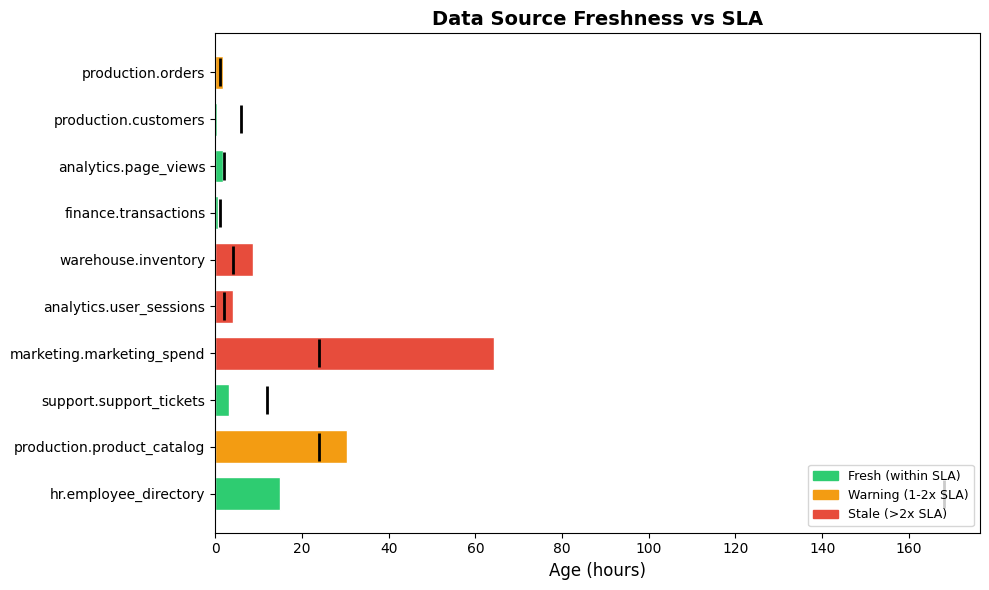

Chart saved to freshness_chart.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

color_map = {"Fresh": "#2ecc71", "Warning": "#f39c12", "Stale": "#e74c3c"}
colors = [color_map[s] for s in df["status"]]

y_pos = range(len(df))
bars = ax.barh(y_pos, df["age_hours"], color=colors, edgecolor="white", height=0.7)

# SLA threshold markers
for i, (_, row) in enumerate(df.iterrows()):
    ax.plot(row["sla_hours"], i, "k|", markersize=20, markeredgewidth=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(df["source"], fontsize=10)
ax.set_xlabel("Age (hours)", fontsize=12)
ax.set_title("Data Source Freshness vs SLA", fontsize=14, fontweight="bold")
ax.invert_yaxis()

legend_patches = [
    mpatches.Patch(color="#2ecc71", label="Fresh (within SLA)"),
    mpatches.Patch(color="#f39c12", label="Warning (1-2x SLA)"),
    mpatches.Patch(color="#e74c3c", label="Stale (>2x SLA)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.axvline(x=0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.savefig("freshness_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to freshness_chart.png")

## Step 4: SLA Breach History (7-Day Trend)

Simulating a week of freshness checks to show breach trends over time.

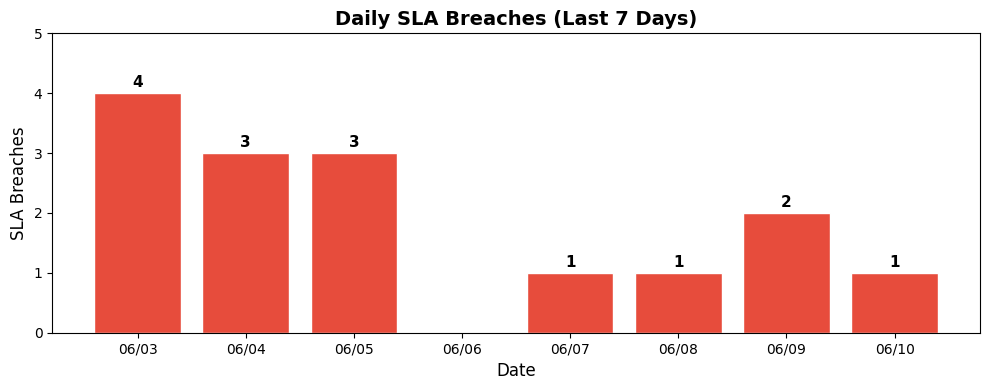

Chart saved to breach_trend.png


In [4]:
random.seed(123)
days = 7
base = datetime(2026, 6, 10, 9, 0, 0)
history_rows = []

for day_offset in range(days, -1, -1):
    date_str = (base - timedelta(days=day_offset)).strftime("%m/%d")
    breaches = sum(1 for s in SOURCES if random.random() < 0.15)
    history_rows.append({"date": date_str, "breaches": breaches})

hist_df = pd.DataFrame(history_rows)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#e74c3c" if b > 0 else "#2ecc71" for b in hist_df["breaches"]]
ax.bar(hist_df["date"], hist_df["breaches"], color=bar_colors, edgecolor="white")
ax.set_ylabel("SLA Breaches", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.set_title("Daily SLA Breaches (Last 7 Days)", fontsize=14, fontweight="bold")
ax.set_ylim(0, max(hist_df["breaches"]) + 1)

for i, v in enumerate(hist_df["breaches"]):
    if v > 0:
        ax.text(i, v + 0.1, str(v), ha="center", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("breach_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to breach_trend.png")

## Step 5: Worst Offenders

Which sources are furthest past their SLA? These need immediate attention.

In [5]:
df["sla_ratio"] = (df["age_hours"] / df["sla_hours"]).round(1)
worst = df[df["status"] != "Fresh"].sort_values("sla_ratio", ascending=False)

print("=== Sources Needing Attention ===")
print()
if len(worst) == 0:
    print("All sources are fresh! 🎉")
else:
    for _, row in worst.iterrows():
        icon = "🔴" if row["status"] == "Stale" else "⚠️"
        print(f"  {icon} {row['source']}")
        print(f"     Age: {row['age_hours']}h | SLA: {row['sla_hours']}h | {row['sla_ratio']}x over | Owner: {row['owner']}")
        print()

=== Sources Needing Attention ===

  🔴 marketing.marketing_spend
     Age: 64.2h | SLA: 24h | 2.7x over | Owner: marketing-ops

  🔴 warehouse.inventory
     Age: 8.8h | SLA: 4h | 2.2x over | Owner: supply-chain

  🔴 analytics.user_sessions
     Age: 4.1h | SLA: 2h | 2.0x over | Owner: analytics

  ⚠️ production.orders
     Age: 1.9h | SLA: 1h | 1.9x over | Owner: data-eng

  ⚠️ production.product_catalog
     Age: 30.4h | SLA: 24h | 1.3x over | Owner: product-eng



## Summary

| Metric | Value |
|--------|-------|
| Total sources monitored | 10 |
| Sources within SLA | Varies by run |
| Sources needing attention | See above |

**Key takeaways:**
- Freshness monitoring catches stale data *before* dashboards mislead stakeholders
- SLA thresholds should be set per-source based on business criticality
- Historical trend tracking reveals systemic reliability issues

## Try Your Own

Modify the sources list below and re-run to monitor your own data:

In [6]:
# my_sources = [
#     {"name": "sales_daily", "schema": "analytics", "owner": "your-team", "sla_hours": 4},
#     {"name": "user_events", "schema": "clickstream", "owner": "data-eng", "sla_hours": 1},
# ]
# my_results = simulate_freshness(my_sources, seed=99)
# pd.DataFrame(my_results)

---

**Part of the [FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** | Run the full Streamlit dashboard: `streamlit run app.py`